# 🚗 Initial Phase Number Plate Detection + Auto-Annotation

In [2]:
# Cell 1 - Install
!pip install ultralytics datasets -q
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.4 MB/s eta 0:00:0000:01
GPU: Tesla P100-PCIE-16GB


In [4]:
# Cell 2 - Fixed paths (no unzip needed)
import shutil
from pathlib import Path

SRC1 = Path("/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj_train_data")
SRC2 = Path("/kaggle/input/datasets/abdullahaamir13/plates-model3/batch02-model3/obj_train_data")

print("Batch01:", len(list(SRC1.glob("*.jpg"))), "images")
print("Batch02:", len(list(SRC2.glob("*.jpg"))), "images")

Batch01: 50 images
Batch02: 50 images


In [7]:
# Cell 3 - Direct Parquet download
import pandas as pd
import requests
from pathlib import Path
from PIL import Image
import io

# Download parquet files directly
train_url = "https://huggingface.co/datasets/keremberke/license-plate-object-detection/resolve/refs%2Fconvert%2Fparquet/full/train/0000.parquet"
val_url   = "https://huggingface.co/datasets/keremberke/license-plate-object-detection/resolve/refs%2Fconvert%2Fparquet/full/validation/0000.parquet"

!wget -q "{train_url}" -O /kaggle/working/train.parquet
!wget -q "{val_url}"   -O /kaggle/working/val.parquet

train_df = pd.read_parquet("/kaggle/working/train.parquet")
val_df   = pd.read_parquet("/kaggle/working/val.parquet")

print(f"Train rows: {len(train_df)}")
print(f"Val rows:   {len(val_df)}")
print(f"Columns: {train_df.columns.tolist()}")

Train rows: 6176
Val rows:   1765
Columns: ['image_id', 'image', 'width', 'height', 'objects']


In [8]:
# Cell 4 - Convert Parquet to YOLO format
import pandas as pd
from pathlib import Path
from PIL import Image
import io

def convert_parquet_to_yolo(df, split_name, out_dir):
    img_dir = Path(out_dir) / "images" / split_name
    lbl_dir = Path(out_dir) / "labels" / split_name
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    for i, row in df.iterrows():
        # Save image
        img_bytes = row['image']['bytes']
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        W, H = img.size
        img.save(img_dir / f"plate_{i:05d}.jpg")

        # Save label
        with open(lbl_dir / f"plate_{i:05d}.txt", "w") as f:
            for bbox in row['objects']['bbox']:
                x, y, w, h = bbox
                cx = min(max((x + w/2) / W, 0), 1)
                cy = min(max((y + h/2) / H, 0), 1)
                bw = min(max(w / W, 0), 1)
                bh = min(max(h / H, 0), 1)
                f.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

    print(f"{split_name}: {len(df)} images saved")

convert_parquet_to_yolo(train_df, "train",      "/kaggle/working/plates_final")
convert_parquet_to_yolo(val_df,   "validation", "/kaggle/working/plates_final")

train: 6176 images saved
validation: 1765 images saved


In [9]:
# Cell 5 - Add your 100 Pakistani plates
import shutil
from pathlib import Path

SRC1      = Path("/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj_train_data")
SRC2      = Path("/kaggle/input/datasets/abdullahaamir13/plates-model3/batch02-model3/obj_train_data")
TRAIN_IMG = Path("/kaggle/working/plates_final/images/train")
TRAIN_LBL = Path("/kaggle/working/plates_final/labels/train")

added = 0
for src in [SRC1, SRC2]:
    for img in src.glob("*.jpg"):
        shutil.copy(img, TRAIN_IMG / f"pak_{img.name}")
        lbl = img.with_suffix(".txt")
        if lbl.exists():
            shutil.copy(lbl, TRAIN_LBL / f"pak_{lbl.name}")
            added += 1

print(f"Pakistani plates added: {added}")
print(f"Total train: {len(list(TRAIN_IMG.glob('*.jpg')))}")
print(f"Total val:   {len(list(Path('/kaggle/working/plates_final/images/validation').glob('*.jpg')))}")

Pakistani plates added: 100
Total train: 6276
Total val:   1765


In [10]:
# Cell 6 - dataset.yaml
import yaml

config = {
    "path": "/kaggle/working/plates_final",
    "train": "images/train",
    "val":   "images/validation",
    "nc": 1,
    "names": {0: "number_plate"}
}

with open("/kaggle/working/plates_final/dataset.yaml", "w") as f:
    yaml.dump(config, f, default_flow_style=False)

!cat /kaggle/working/plates_final/dataset.yaml

names:
  0: number_plate
nc: 1
path: /kaggle/working/plates_final
train: images/train
val: images/validation


In [11]:
# Cell 7 - Train
!yolo task=detect \
      mode=train \
      model=yolov8s.pt \
      data=/kaggle/working/plates_final/dataset.yaml \
      epochs=50 \
      imgsz=640 \
      batch=16 \
      patience=15 \
      name=plates_model3 \
      project=/kaggle/working/runs \
      device=0 \
      exist_ok=True \
      cos_lr=True \
      mosaic=1.0

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/plates_final/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=

In [12]:
# Final cell - zip all outputs
import shutil

shutil.make_archive(
    "/kaggle/working/plates_model3_results",
    "zip",
    "/kaggle/working/runs/plates_model3"
)
print("Done. Download plates_model3_results.zip from Output tab.")

Done. Download plates_model3_results.zip from Output tab.


In [21]:
# Cell 8 - Find and load best.pt from output dataset
import os, zipfile
from pathlib import Path

# Check what's available
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj.names
/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj.data
/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/train.txt
/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj_train_data/03210000104.jpg
/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj_train_data/000000017.jpg
/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj_train_data/03210000109.txt
/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj_train_data/03210000058.txt
/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj_train_data/000000010.txt
/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj_train_data/03210000037.txt
/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj_train_data/03210000006.jpg
/kaggle/input/datasets/abdullahaamir13/plates-model3/batch01-model3/obj_train_

In [3]:
# Cell 8 - Load model (no extraction needed!)
from ultralytics import YOLO
from pathlib import Path

model = YOLO("/kaggle/input/datasets/abdullahaamir13/plates-model03-results/weights/best.pt")

BUS_IMAGES = Path("/kaggle/input/datasets/abdullahaamir13/busesnpmodel03/NOT")
print(f"Model loaded!!!")
print(f"Bus images found: {len(list(BUS_IMAGES.glob('*.jpg')))}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded!!!
Bus images found: 1544


In [4]:
# Cell 9 - Auto-annotate
import shutil
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/plate_auto_annotations")
IMG_OUT    = OUTPUT_DIR / "obj_train_data"
IMG_OUT.mkdir(parents=True, exist_ok=True)

results = model.predict(
    source=str(BUS_IMAGES),
    conf=0.30,
    iou=0.45,
    imgsz=640,
    save=False,
    verbose=False
)

detected = no_plate = 0

for r in results:
    img_path = Path(r.path)
    lbl_path = IMG_OUT / (img_path.stem + ".txt")
    shutil.copy(img_path, IMG_OUT / img_path.name)

    if r.boxes is None or len(r.boxes) == 0:
        lbl_path.touch()
        no_plate += 1
        continue

    with open(lbl_path, "w") as f:
        for box in r.boxes:
            cx, cy, bw, bh = box.xywhn[0].tolist()
            f.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")
    detected += 1

print(f"Plates detected:  {detected}")
print(f"No plate found:   {no_plate}")
print(f"Detection rate:   {detected/(detected+no_plate)*100:.1f}%")

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs



Corrupt JPEG data: 1 extraneous bytes before marker 0xd9


Plates detected:  1011
No plate found:   533
Detection rate:   65.5%


In [5]:
# Cell 10 - Package for CVAT
with open(OUTPUT_DIR / "obj.names", "w") as f:
    f.write("number_plate\n")

with open(OUTPUT_DIR / "obj.data", "w") as f:
    f.write("classes = 1\ntrain = train.txt\nnames = obj.names\n")

images = sorted(IMG_OUT.glob("*.jpg"))
with open(OUTPUT_DIR / "train.txt", "w") as f:
    for img in images:
        f.write(f"obj_train_data/{img.name}\n")

shutil.make_archive("/kaggle/working/plates_bus_auto_cvat", "zip", OUTPUT_DIR)
print(f"Total images: {len(images)}")
print("Download plates_bus_auto_cvat.zip from Output tab!!!")

Total images: 1544
Download plates_bus_auto_cvat.zip from Output tab!!!


# 🚗 Number Plate Detection + OCR Model04

**Only 2 datasets needed:**
| Dataset | Role |
|---|---|
| `abdullahaamir13/numberplatesmodel03` | All training data (batch03 annotated + model3 train/val) |
| `abdullahaamir13/plates-model03-results` | Model03 best.pt — fine-tune starting point |

**Pipeline:** Merge data → validate → fine-tune YOLOv8s → OCR with EasyOCR → batch inference → export

### Retraining (Fine-Tuning)

In [17]:
# ─────────────────────────────────────────────
# Cell 1 — Install
# ─────────────────────────────────────────────
!pip install ultralytics easyocr -q
import torch
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.version.cuda}")
print(f"Torch: {torch.__version__}")

GPU : Tesla P100-PCIE-16GB
CUDA: 12.6
Torch: 2.9.0+cu126


## Step 1 Verify Inputs

In [18]:
# ─────────────────────────────────────────────
# Cell 2 — Check all input paths
# ─────────────────────────────────────────────
import os
from pathlib import Path

BASE       = Path("/kaggle/input/datasets/abdullahaamir13/numberplatesmodel03")
BATCH03    = BASE / "batch03-model3/obj_train_data"
M3_TRAIN   = BASE / "model3/model3/train"
M3_VAL     = BASE / "model3/model3/val"
MODEL03_PT = Path("/kaggle/input/datasets/abdullahaamir13/plates-model03-results/weights/best.pt")

checks = {
    "batch03 corrected annotations": BATCH03,
    "model3 YOLO train split      ": M3_TRAIN,
    "model3 YOLO val split        ": M3_VAL,
    "Model03 best.pt              ": MODEL03_PT,
}
all_ok = True
for name, p in checks.items():
    if p.is_file():
        size = os.path.getsize(p) / 1e6
        print(f"  ✅  {name}  ({size:.1f} MB)")
    elif p.is_dir():
        n_jpg  = len(list(p.glob("*.jpg")))
        n_png  = len(list(p.glob("*.png")))
        n_txt  = len(list(p.glob("*.txt")))
        if n_jpg == 0:
            n_jpg  = len(list(p.glob("images/*.jpg")))
            n_png  = len(list(p.glob("images/*.png")))
            n_txt  = len(list(p.glob("labels/*.txt")))
        print(f"  ✅  {name}  ({n_jpg} jpg | {n_png} png | {n_txt} labels)")
    else:
        print(f"  ❌  {name}  MISSING → {p}")
        all_ok = False

print()
print(" All inputs found!" if all_ok else " Fix missing paths above.")

  ✅  batch03 corrected annotations  (1119 jpg | 0 png | 1119 labels)
  ✅  model3 YOLO train split        (476 jpg | 2 png | 478 labels)
  ✅  model3 YOLO val split          (120 jpg | 0 png | 120 labels)
  ✅  Model03 best.pt                (22.5 MB)

 All inputs found!


## Step 2 Build Dataset

In [19]:
# ─────────────────────────────────────────────
# Cell 3 — Merge batch03 + model3 into YOLO structure
#           Fixed: JPG + PNG both copied
# ─────────────────────────────────────────────
import shutil
from pathlib import Path

ROOT = Path("/kaggle/working/plates_model4")
TI   = ROOT / "images/train"
TL   = ROOT / "labels/train"
VI   = ROOT / "images/validation"
VL   = ROOT / "labels/validation"

for d in [TI, TL, VI, VL]:
    d.mkdir(parents=True, exist_ok=True)

BASE    = Path("/kaggle/input/datasets/abdullahaamir13/numberplatesmodel03")
BATCH03 = BASE / "batch03-model3/obj_train_data"

# SOURCE 1: batch03 flat jpg+txt pairs (JPG + PNG)
bus_pos = bus_neg = 0
for ext in ["*.jpg", "*.jpeg", "*.png"]:
    for img in BATCH03.glob(ext):
        lbl = img.with_suffix(".txt")
        if not lbl.exists():
            continue
        shutil.copy(img, TI / f"bus_{img.name}")
        shutil.copy(lbl, TL / f"bus_{lbl.name}")
        if lbl.stat().st_size > 0:
            bus_pos += 1
        else:
            bus_neg += 1
print(f"[1/2] batch03: {bus_pos} with plates  |  {bus_neg} negatives")

# SOURCE 2: model3 train/val (JPG + PNG)
def copy_split(split_root, img_dst, lbl_dst, prefix):
    img_src = split_root / "images"
    lbl_src = split_root / "labels"
    added = 0
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        for img in img_src.glob(ext):
            lbl = lbl_src / (img.stem + ".txt")
            if lbl.exists():
                shutil.copy(img, img_dst / f"{prefix}_{img.name}")
                shutil.copy(lbl, lbl_dst / f"{prefix}_{lbl.name}")
                added += 1
    return added

n_train = copy_split(BASE / "model3/model3/train", TI, TL, "m3")
n_val   = copy_split(BASE / "model3/model3/val",   VI, VL, "m3v")
print(f"[2/2] model3 splits: train={n_train}  |  val={n_val}")
print(f"\nTotal train : {len(list(TI.glob('*.jpg'))):,}")
print(f"Total val   : {len(list(VI.glob('*.jpg'))):,}")

[1/2] batch03: 993 with plates  |  126 negatives
[2/2] model3 splits: train=477  |  val=119

Total train : 1,594
Total val   : 119


In [23]:
# Cell 4 — Re-balance val: add 10% of batch03 into val
import shutil, random
from pathlib import Path

TI = Path("/kaggle/working/plates_model4/images/train")
TL = Path("/kaggle/working/plates_model4/labels/train")
VI = Path("/kaggle/working/plates_model4/images/validation")
VL = Path("/kaggle/working/plates_model4/labels/validation")

bus_train_imgs = list(TI.glob("bus_*.jpg")) + list(TI.glob("bus_*.png"))
random.seed(42)
random.shuffle(bus_train_imgs)

split_n = max(1, int(len(bus_train_imgs) * 0.10))  # ~112 images
moved = 0
for img in bus_train_imgs[:split_n]:
    lbl = TL / (img.stem + ".txt")
    shutil.move(str(img), VI / img.name)
    if lbl.exists():
        shutil.move(str(lbl), VL / lbl.name)
    moved += 1

print(f" batch03 val moved: {moved} images")

# Final counts
train_total = len(list(TI.glob("*.jpg"))) + len(list(TI.glob("*.png")))
val_total   = len(list(VI.glob("*.jpg"))) + len(list(VI.glob("*.png")))

bus_val  = len(list(VI.glob("bus_*.jpg")))
m3v_val  = len(list(VI.glob("m3v_*.jpg")))
print(f"\nVal breakdown:")
print(f"  bus_ (batch03) : {bus_val}")
print(f"  m3v_ (model3)  : {m3v_val}")
print(f"  Total val      : {val_total}")
print(f"\nFinal → train: {train_total:,}  |  val: {val_total:,}")

 batch03 val moved: 100 images

Val breakdown:
  bus_ (batch03) : 211
  m3v_ (model3)  : 119
  Total val      : 330

Final → train: 1,385  |  val: 330


In [25]:
# ─────────────────────────────────────────────
# Cell 5 — Validate all labels
# ─────────────────────────────────────────────
from pathlib import Path

errors = []
label_stats = {"train": {"total": 0, "empty": 0}, "val": {"total": 0, "empty": 0}}

for split, img_dir, lbl_dir in [
    ("train", Path("/kaggle/working/plates_model4/images/train"),
               Path("/kaggle/working/plates_model4/labels/train")),
    ("val",   Path("/kaggle/working/plates_model4/images/validation"),
               Path("/kaggle/working/plates_model4/labels/validation")),
]:
    imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    for img in imgs:
        lbl = lbl_dir / (img.stem + ".txt")
        label_stats[split]["total"] += 1
        if not lbl.exists():
            errors.append(f"MISSING_LABEL: {img.name}")
            continue
        content = lbl.read_text().strip()
        if not content:
            label_stats[split]["empty"] += 1
            continue  # negative sample — ok
        for ln, line in enumerate(content.splitlines(), 1):
            if not line.strip():
                continue
            parts = line.split()
            if len(parts) != 5:
                errors.append(f"BAD_COLS({len(parts)}): {lbl.name}:L{ln}")
                continue
            cls_id = int(parts[0])
            if cls_id != 0:
                errors.append(f"WRONG_CLASS={cls_id}: {lbl.name}:L{ln}")
            for v, name in zip(parts[1:], ["cx","cy","bw","bh"]):
                fv = float(v)
                if not (0.0 <= fv <= 1.0):
                    errors.append(f"OUT_OF_RANGE {name}={fv:.4f}: {lbl.name}:L{ln}")

print(f"Train → {label_stats['train']['total']} images | {label_stats['train']['empty']} negatives")
print(f"Val   → {label_stats['val']['total']} images | {label_stats['val']['empty']} negatives")

if errors:
    print(f"\n {len(errors)} label errors (first 30):")
    for e in errors[:30]:
        print(f"   {e}")
else:
    print("\n All labels valid, dataset clean!")

Train → 1385 images | 197 negatives
Val   → 330 images | 73 negatives

 All labels valid, dataset clean!


In [26]:
# ─────────────────────────────────────────────
# Cell 6 — Write dataset.yaml
# ─────────────────────────────────────────────
import yaml

config = {
    "path" : "/kaggle/working/plates_model4",
    "train": "images/train",
    "val"  : "images/validation",
    "nc"   : 1,
    "names": {0: "number_plate"},
}
with open("/kaggle/working/plates_model4/dataset.yaml", "w") as f:
    yaml.dump(config, f, default_flow_style=False)
print(" dataset.yaml written")
!cat /kaggle/working/plates_model4/dataset.yaml

 dataset.yaml written
names:
  0: number_plate
nc: 1
path: /kaggle/working/plates_model4
train: images/train
val: images/validation


## Step 3 Train/Fine-Tune new Model

In [27]:
# ─────────────────────────────────────────────
# Cell 7 — Fine-tune from Model03 weights
#   imgsz 640→800  |  epochs 30→50
#   yolov8m (medium) for better localization
#   scale + degrees augmentation
# ─────────────────────────────────────────────
MODEL03_PT = "/kaggle/input/datasets/abdullahaamir13/plates-model03-results/weights/best.pt"

!yolo task=detect \
      mode=train \
      model={MODEL03_PT} \
      data=/kaggle/working/plates_model4/dataset.yaml \
      epochs=50 \
      imgsz=800 \
      batch=8 \
      patience=15 \
      name=plates_model4 \
      project=/kaggle/working/runs \
      device=0 \
      exist_ok=True \
      cos_lr=True \
      mosaic=1.0 \
      scale=0.5 \
      degrees=5.0 \
      lr0=0.0005 \
      lrf=0.01 \
      warmup_epochs=3 \
      save_period=5 \
      plots=True

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/plates_model4/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/datasets/abdullahaamir13/plates-model03-results/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plates_model4, nbs=64, nms=

## Step 4 Save All Results!!!

In [28]:
# ─────────────────────────────────────────────
# Cell 8 — Model03 vs Model04 Comparison
# ─────────────────────────────────────────────
from ultralytics import YOLO

DATA   = "/kaggle/working/plates_model4/dataset.yaml"
IMGSZ  = 800   # match training imgsz

print("=" * 55)
print("  RUNNING VALIDATION — MODEL03 (baseline)")
print("=" * 55)
m3 = YOLO("/kaggle/input/datasets/abdullahaamir13/plates-model03-results/weights/best.pt")
r3 = m3.val(data=DATA, imgsz=IMGSZ, device=0, verbose=False)

print("=" * 55)
print("  RUNNING VALIDATION — MODEL04 (fine-tuned)")
print("=" * 55)
m4 = YOLO("/kaggle/working/runs/plates_model4/weights/best.pt")
r4 = m4.val(data=DATA, imgsz=IMGSZ, device=0, verbose=False)

# ── Comparison Table ──
print("\n")
print("=" * 58)
print(f"  {'Metric':<14} {'Model03':>10} {'Model04':>10} {'Δ':>10}")
print(f"  {'-'*54}")
metrics = [
    ("Precision",  r3.box.mp,    r4.box.mp),
    ("Recall",     r3.box.mr,    r4.box.mr),
    ("mAP@50",     r3.box.map50, r4.box.map50),
    ("mAP@50-95",  r3.box.map,   r4.box.map),
]
for name, v3, v4 in metrics:
    delta = v4 - v3
    arrow = "✅" if delta > 0 else "❌" if delta < -0.002 else "➡️"
    print(f"  {name:<14} {v3:>10.4f} {v4:>10.4f} {delta:>+9.4f}  {arrow}")
print("=" * 58)

  RUNNING VALIDATION — MODEL03 (baseline)
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2817.0±682.4 MB/s, size: 193.1 KB)
val: Scanning /kaggle/working/plates_model4/labels/validation.cache... 330 images, 73 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 330/330 65.9Mit/s 0.0s


Corrupt JPEG data: 2 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 14% ━╸────────── 3/21 1.3it/s 1.6s<13.5s

Corrupt JPEG data: 2 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 24% ━━╸───────── 5/21 2.8it/s 2.1s<5.8ss

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 24% ━━╸───────── 5/21 2.6it/s 2.9s<6.3ss

Corrupt JPEG data: 1 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 29% ━━━───────── 6/21 3.5it/s 3.1s<4.3s

Corrupt JPEG data: 1 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 3.7it/s 5.6s0.2s
                   all        330        271      0.918      0.875      0.958      0.641
Speed: 2.9ms preprocess, 7.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val2


  Metric            Model03    Model04          Δ
  ------------------------------------------------------
  Precision          0.7894     0.9175   +0.1282  ✅
  Recall             0.7565     0.8745   +0.1181  ✅
  mAP@50             0.7584     0.9576   +0.1992  ✅
  mAP@50-95          0.5116     0.6406   +0.1291  ✅


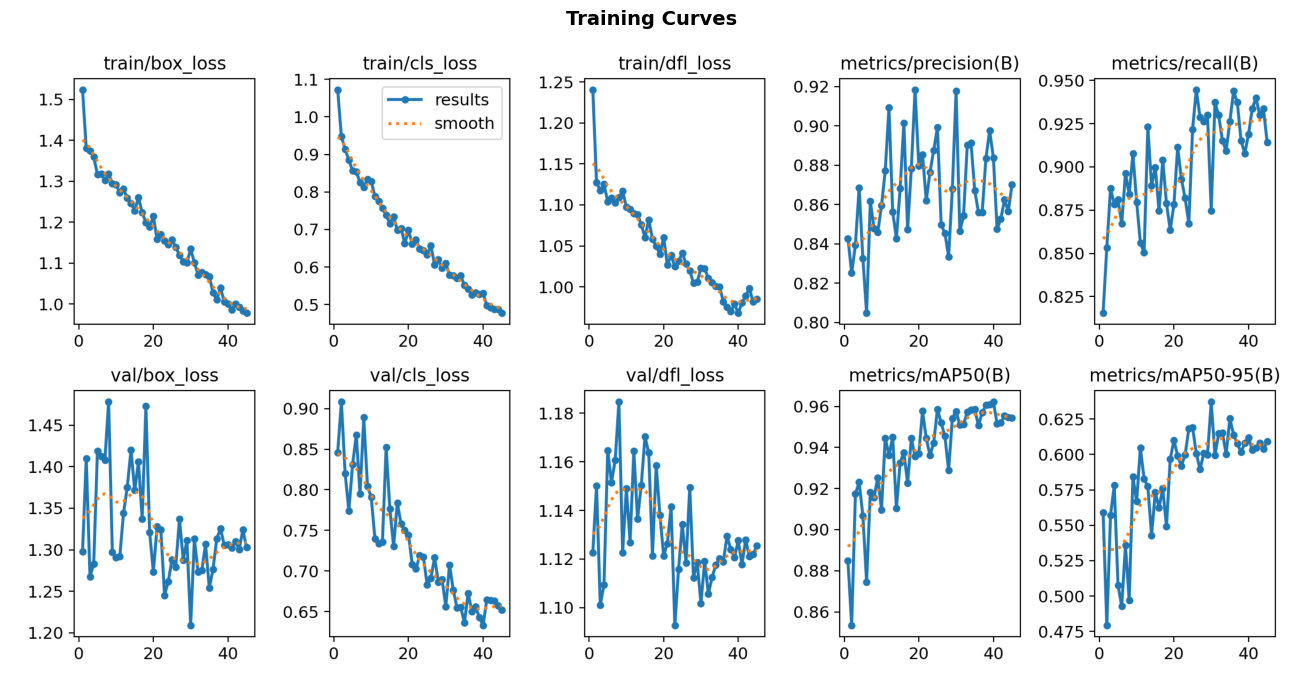

  Not found: PR_curve.png


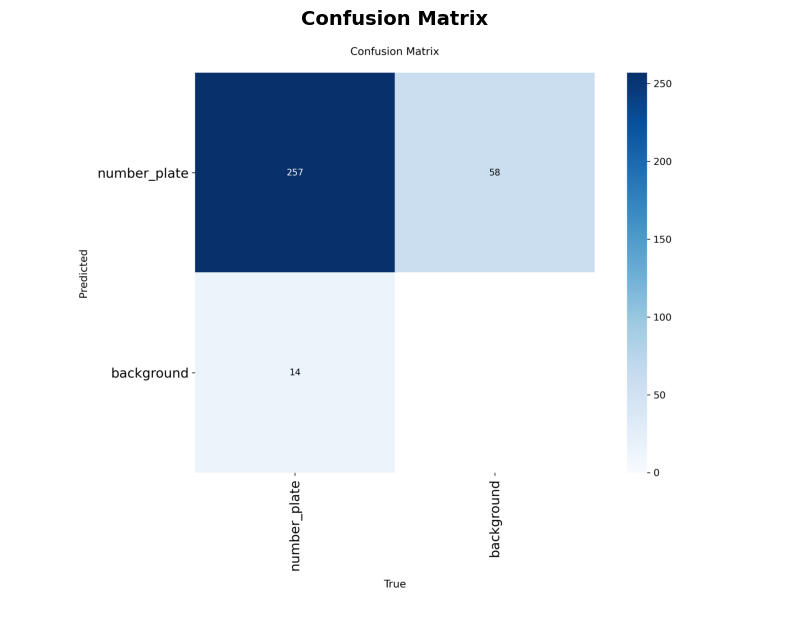

  Not found: F1_curve.png


In [29]:
# ─────────────────────────────────────────────
# Cell 9 — Training Curves + PR + Confusion Matrix
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

RUN = Path("/kaggle/working/runs/plates_model4")

plots = [
    ("Training Curves",   RUN / "results.png",           (16, 7)),
    ("PR Curve",          RUN / "PR_curve.png",           (10, 6)),
    ("Confusion Matrix",  RUN / "confusion_matrix.png",   (8,  7)),
    ("F1 Curve",          RUN / "F1_curve.png",           (10, 6)),
]

for title, path, figsize in plots:
    if path.exists():
        img = mpimg.imread(str(path))
        plt.figure(figsize=figsize)
        plt.imshow(img)
        plt.axis("off")
        plt.title(title, fontsize=14, fontweight="bold", pad=10)
        plt.tight_layout()
        plt.show()
    else:
        print(f"  Not found: {path.name}")

Running inference on 330 val images...


Corrupt JPEG data: 2 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9



  Val images        : 330
  Detected plates   : 277
  Missed (0 detect) : 53
  Avg confidence    : 0.727

  Source breakdown:
    bus_ (batch03) avg conf : 0.729  (222 dets)
    m3v_ (model3)  avg conf : 0.722  (94 dets)


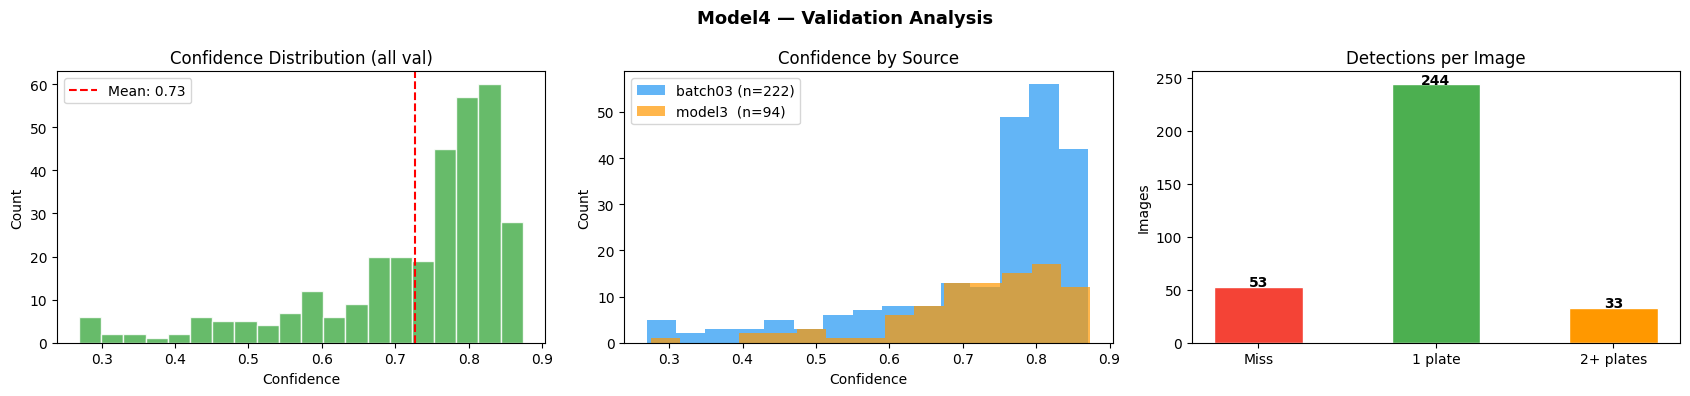

 Saved: val_analysis.png


In [30]:
# ─────────────────────────────────────────────
# Cell 10 — Dynamic Val: Confidence + Detection Breakdown
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from ultralytics import YOLO

VAL_IMGS = Path("/kaggle/working/plates_model4/images/validation")
m4 = YOLO("/kaggle/working/runs/plates_model4/weights/best.pt")

all_imgs = list(VAL_IMGS.glob("*.jpg")) + list(VAL_IMGS.glob("*.png"))
print(f"Running inference on {len(all_imgs)} val images...")

results_all = m4.predict(
    source=str(VAL_IMGS),
    imgsz=800, conf=0.25, device=0,
    verbose=False, save=False,
    stream=True
)

confidences, det_counts = [], []
bus_confs, m3v_confs = [], []  # per-source confidence

for r in results_all:
    fname = Path(r.path).name
    boxes = r.boxes
    if boxes is not None and len(boxes):
        confs = boxes.conf.cpu().numpy().tolist()
        confidences.extend(confs)
        det_counts.append(len(confs))
        if fname.startswith("bus_"):
            bus_confs.extend(confs)
        else:
            m3v_confs.extend(confs)
    else:
        det_counts.append(0)

print(f"\n  Val images        : {len(all_imgs)}")
print(f"  Detected plates   : {sum(1 for c in det_counts if c > 0)}")
print(f"  Missed (0 detect) : {sum(1 for c in det_counts if c == 0)}")
print(f"  Avg confidence    : {np.mean(confidences):.3f}" if confidences else "  No detections")
print(f"\n  Source breakdown:")
print(f"    bus_ (batch03) avg conf : {np.mean(bus_confs):.3f}  ({len(bus_confs)} dets)" if bus_confs else "    bus_: no detections")
print(f"    m3v_ (model3)  avg conf : {np.mean(m3v_confs):.3f}  ({len(m3v_confs)} dets)" if m3v_confs else "    m3v_: no detections")

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("Model4 — Validation Analysis", fontsize=13, fontweight="bold")

# 1. Confidence histogram
if confidences:
    axes[0].hist(confidences, bins=20, color="#4CAF50", edgecolor="white", alpha=0.85)
    axes[0].axvline(np.mean(confidences), color="red", linestyle="--",
                    label=f"Mean: {np.mean(confidences):.2f}")
    axes[0].set_title("Confidence Distribution (all val)")
    axes[0].set_xlabel("Confidence")
    axes[0].set_ylabel("Count")
    axes[0].legend()

# 2. Per-source confidence
axes[1].hist(bus_confs, bins=15, alpha=0.7, color="#2196F3", label=f"batch03 (n={len(bus_confs)})")
axes[1].hist(m3v_confs, bins=15, alpha=0.7, color="#FF9800", label=f"model3  (n={len(m3v_confs)})")
axes[1].set_title("Confidence by Source")
axes[1].set_xlabel("Confidence")
axes[1].set_ylabel("Count")
axes[1].legend()

# 3. Detection count per image
counts = [
    sum(1 for c in det_counts if c == 0),
    sum(1 for c in det_counts if c == 1),
    sum(1 for c in det_counts if c >= 2),
]
bars = axes[2].bar(["Miss", "1 plate", "2+ plates"],
                   counts, color=["#F44336","#4CAF50","#FF9800"],
                   edgecolor="white", width=0.5)
for bar, val in zip(bars, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha="center", fontweight="bold")
axes[2].set_title("Detections per Image")
axes[2].set_ylabel("Images")

plt.tight_layout()
plt.savefig("/kaggle/working/val_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: val_analysis.png")

/tmp/ipykernel_55/1431626664.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1431626664.py:52: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1431626664.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/sample_predictions.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_55/1431626664.py:53: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/sample_predictions.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) m

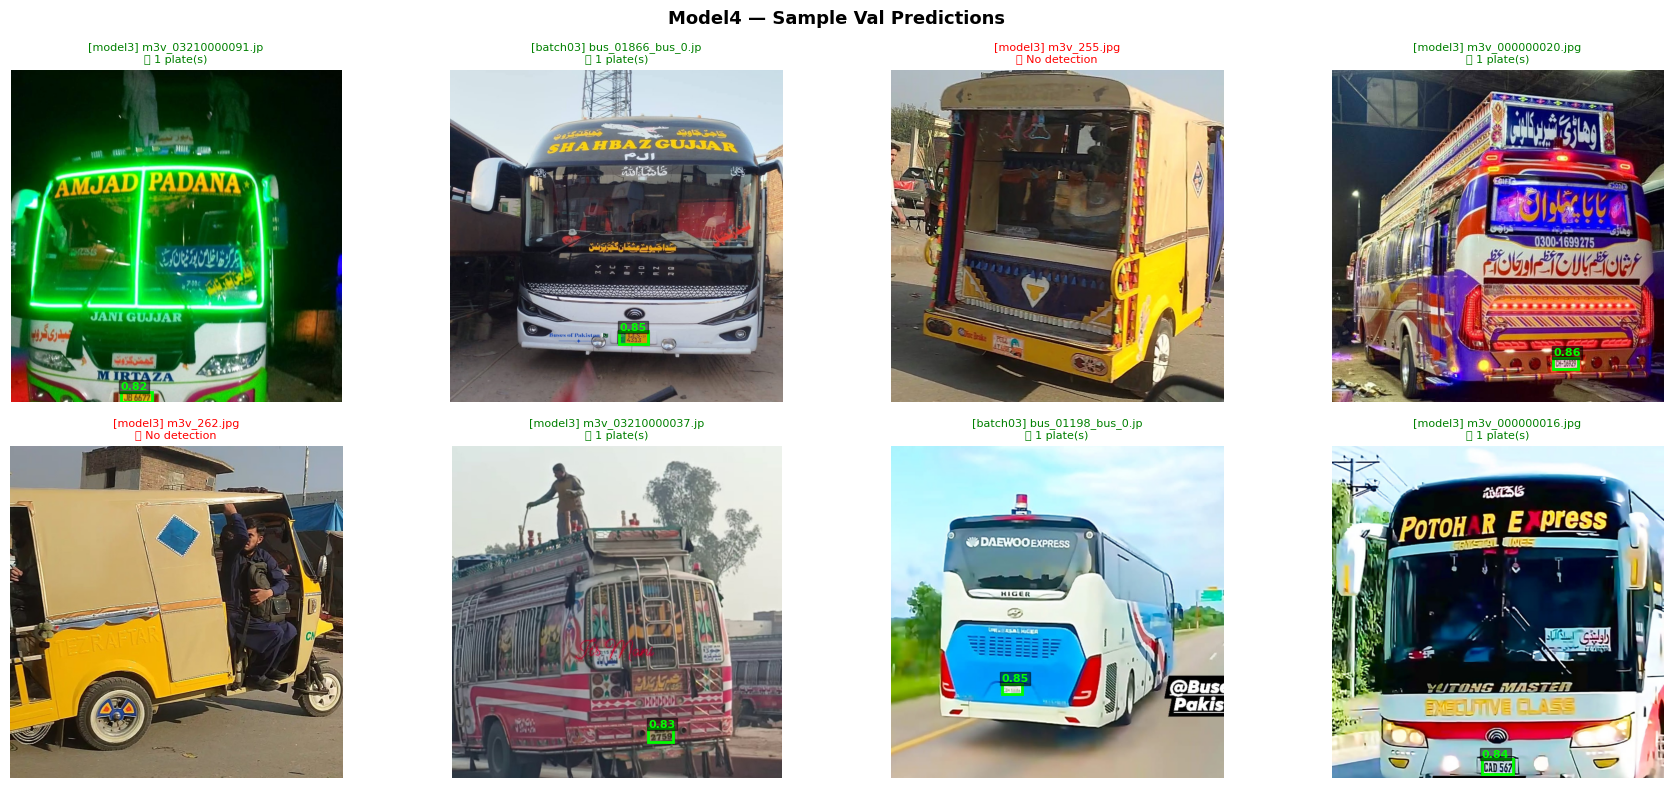

 Saved: sample_predictions.png


In [31]:
# ─────────────────────────────────────────────
# Cell 11 — Sample Predictions (8 random val images)
# ─────────────────────────────────────────────
import random, cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from pathlib import Path
from ultralytics import YOLO

VAL_IMGS = Path("/kaggle/working/plates_model4/images/validation")
m4 = YOLO("/kaggle/working/runs/plates_model4/weights/best.pt")

all_imgs    = list(VAL_IMGS.glob("*.jpg")) + list(VAL_IMGS.glob("*.png"))
sample_imgs = random.sample(all_imgs, min(8, len(all_imgs)))

results_s = m4.predict(
    source=[str(s) for s in sample_imgs],
    imgsz=800, conf=0.25, device=0,
    verbose=False, save=False
)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Model4 — Sample Val Predictions", fontsize=13, fontweight="bold")
axes = axes.flatten()

for ax, (img_path, r) in zip(axes, zip(sample_imgs, results_s)):
    img_arr = mpimg.imread(str(img_path))
    ax.imshow(img_arr)
    ax.axis("off")
    h, w = img_arr.shape[:2]

    boxes = r.boxes
    if boxes is not None and len(boxes):
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].item()
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=2, edgecolor="#00FF00", facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"{conf:.2f}", color="#00FF00", fontsize=8,
                    fontweight="bold",
                    bbox=dict(facecolor="black", alpha=0.5, pad=1))
        label, col = f"✅ {len(boxes)} plate(s)", "green"
    else:
        label, col = "❌ No detection", "red"

    src = "batch03" if img_path.name.startswith("bus_") else "model3"
    ax.set_title(f"[{src}] {img_path.name[:18]}\n{label}",
                 color=col, fontsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: sample_predictions.png")

In [32]:
# ─────────────────────────────────────────────
# Cell 12 — Export ONNX
# ─────────────────────────────────────────────
import shutil
from ultralytics import YOLO

shutil.copy(
    "/kaggle/working/runs/plates_model4/weights/best.pt",
    "/kaggle/working/best_model4.pt"
)
m4 = YOLO("/kaggle/working/best_model4.pt")
m4.export(format="onnx", imgsz=640, dynamic=False, simplify=True, opset=12)
print(" ONNX exported → /kaggle/working/best_model4.onnx")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/kaggle/working/best_model4.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 192ms
Prepared 2 packages in 2.31s
Installed 2 packages in 11ms
 + onnxruntime-gpu==1.24.2
 + onnxslim==0.1.86

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 12...
ONNX: slimming with onnxslim 0.1.86...
ONNX: export success ✅ 4.8s, saved as '/ka

In [33]:
# ─────────────────────────────────────────────
# Cell 13 — Package everything for download
# ─────────────────────────────────────────────
import shutil, os, json
from pathlib import Path
from IPython.display import FileLink, display
from ultralytics import YOLO

OUT = Path("/kaggle/working")

# Save metrics JSON
m4  = YOLO(str(OUT / "runs/plates_model4/weights/best.pt"))
r4  = m4.val(data="/kaggle/working/plates_model4/dataset.yaml",
             imgsz=800, device=0, verbose=False)
summary = {
    "model"     : "plates_model4",
    "mAP50"     : round(float(r4.box.map50), 4),
    "mAP50_95"  : round(float(r4.box.map),   4),
    "precision" : round(float(r4.box.mp),    4),
    "recall"    : round(float(r4.box.mr),    4),
    "vs_model3" : {
        "mAP50_delta"   : round(float(r4.box.map50 - 0.926), 4),
        "mAP5095_delta" : round(float(r4.box.map   - 0.610), 4),
    }
}
with open(OUT / "model4_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)
print("✅ model4_metrics.json saved")
print(json.dumps(summary, indent=2))

# Zip packages
packages = {
    "model4_weights.zip"     : ("/kaggle/working/runs/plates_model4/weights", None),
    "model4_full_results.zip": ("/kaggle/working/runs/plates_model4",         None),
    "model4_onnx.zip"        : (str(OUT), "best_model4.onnx"),
}
for fname, (src, base) in packages.items():
    shutil.make_archive(str(OUT / fname.replace(".zip","")), "zip", src, base)

print("\n" + "=" * 50)
print("  ALL DOWNLOAD FILES READY")
print("=" * 50)
labels = {
    "model4_weights.zip"     : "best.pt + last.pt",
    "model4_full_results.zip": "Training curves, graphs, all logs",
    "model4_onnx.zip"        : "ONNX model for deployment",
    "model4_metrics.json"    : "mAP / precision / recall summary",
    "val_analysis.png"       : "Confidence + detection breakdown chart",
    "sample_predictions.png" : "8 sample val predictions",
}
for fname, desc in labels.items():
    p = OUT / fname
    if p.exists():
        size = os.path.getsize(p) / 1e6
        print(f"\n {fname} ({size:.1f} MB)\n     {desc}")
        display(FileLink(str(p)))
    else:
        print(f" {fname} , not found!!!")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3165.3±505.5 MB/s, size: 611.0 KB)
val: Scanning /kaggle/working/plates_model4/labels/validation.cache... 330 images, 73 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 330/330 138.4Mit/s 0.0s


Corrupt JPEG data: 2 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 14% ━╸────────── 3/21 1.1it/s 2.3s<16.2s

Corrupt JPEG data: 2 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2 extraneous bytes before marker 0xd9


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 24% ━━╸───────── 5/21 2.7it/s 2.9s<6.0ss

...

/kaggle/working/model4_metrics.json


 val_analysis.png (0.1 MB)
     Confidence + detection breakdown chart


/kaggle/working/val_analysis.png


 sample_predictions.png (3.1 MB)
     8 sample val predictions


/kaggle/working/sample_predictions.png

## Step 5 OCR Pipeline

`Image → YOLOv8 detect plate → crop → preprocess → EasyOCR → text`

In [39]:
# ─────────────────────────────────────────────
# Cell 14 — Load Model04 + EasyOCR
# ─────────────────────────────────────────────
import easyocr
from ultralytics import YOLO

detector = YOLO("/kaggle/working/runs/plates_model4/weights/best.pt")
reader   = easyocr.Reader(["en"], gpu=True, verbose=False)
print("Model04 loaded!!!")
print("EasyOCR loaded!!!")

Model04 loaded!!!
EasyOCR loaded!!!


In [40]:
# ─────────────────────────────────────────────
# Cell 15 — Preprocessing + OCR helpers
# ─────────────────────────────────────────────
import cv2, numpy as np, re

def preprocess_plate_crop(crop: np.ndarray) -> np.ndarray:
    h, w = crop.shape[:2]
    if w < 300:
        crop = cv2.resize(crop, (300, int(h * 300/w)), interpolation=cv2.INTER_CUBIC)
    gray   = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray   = cv2.fastNlMeansDenoising(gray, h=10)
    thresh = cv2.adaptiveThreshold(gray, 255,
                 cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 10)
    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    return cv2.filter2D(thresh, -1, kernel)

def clean_plate_text(raw: str) -> str:
    cleaned = re.sub(r"[^A-Z0-9\-]", "", raw.upper()).strip()
    return cleaned

print("Helpers defined!")

Helpers defined!


In [41]:
# ─────────────────────────────────────────────
# Cell 16 — detect_and_read_plate() function
# ─────────────────────────────────────────────
import cv2, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg

def detect_and_read_plate(image_path: str, conf: float = 0.35, show: bool = True) -> list:
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(image_path)
    H, W    = img_bgr.shape[:2]
    results = []

    for r in detector.predict(source=image_path, conf=conf, iou=0.45,
                               imgsz=800, verbose=False, stream=True):
        for box in (r.boxes or []):
            x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
            det_conf     = float(box.conf[0])
            px = int((x2-x1)*0.05); py = int((y2-y1)*0.05)
            crop      = img_bgr[max(0,y1-py):min(H,y2+py),
                                max(0,x1-px):min(W,x2+px)]
            processed = preprocess_plate_crop(crop)
            ocr_out   = reader.readtext(processed, detail=1, paragraph=False)
            raw_text  = " ".join(seg[1] for seg in
                                 sorted(ocr_out, key=lambda s: s[0][0][0]))
            clean     = clean_plate_text(raw_text)
            results.append({"bbox":[x1,y1,x2,y2], "conf":det_conf,
                             "text":clean, "raw":raw_text})

    if show and results:
        vis = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
        for d in results:
            x1,y1,x2,y2 = d["bbox"]
            label = f"{d['text']}  {d['conf']:.0%}"
            cv2.rectangle(vis, (x1,y1), (x2,y2), (0,220,0), 3)
            cv2.rectangle(vis, (x1,max(0,y1-36)),
                          (x1+len(label)*13, y1), (0,220,0), -1)
            cv2.putText(vis, label, (x1+4, y1-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)
        plt.figure(figsize=(14,7))
        plt.imshow(vis); plt.axis("off")
        plt.title(f"{len(results)} plate(s) detected")
        plt.show()
    elif show:
        print("No plates detected.")

    return results

print(" detect_and_read_plate() ready!")

 detect_and_read_plate() ready!


Test image: /kaggle/input/datasets/abdullahaamir13/numberplatesmodel03/batch03-model3/obj_train_data/01008_bus_0.jpg



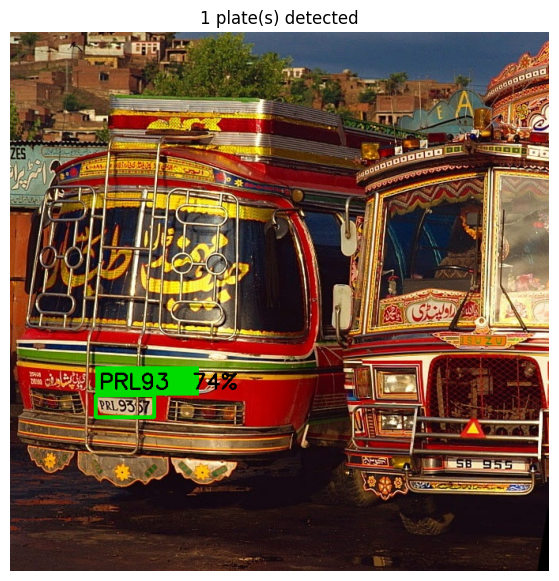

Plate #1  conf=74.3%  text='PRL93'  raw='PRL93'


In [48]:
# ─────────────────────────────────────────────
# Cell 17 — Test on one batch03 image
# ─────────────────────────────────────────────
from pathlib import Path

test_imgs = sorted(
    Path("/kaggle/input/datasets/abdullahaamir13/numberplatesmodel03"
         "/batch03-model3/obj_train_data").glob("*.jpg")
)
if test_imgs:
    img = str(test_imgs[10])
    print(f"Test image: {img}\n")
    results = detect_and_read_plate(img, conf=0.35, show=True)
    for i, r in enumerate(results, 1):
        print(f"Plate #{i}  conf={r['conf']:.1%}  "
              f"text='{r['text']}'  raw='{r['raw']}'")
else:
    print(" No images found — check BATCH03 path.")

## Step 6 Batch Inference → CSV

In [49]:
# ─────────────────────────────────────────────
# Cell 18 — Batch OCR on all batch03 → CSV
# ─────────────────────────────────────────────
import csv
from pathlib import Path

INPUT_DIR  = Path("/kaggle/input/datasets/abdullahaamir13/numberplatesmodel03"
                  "/batch03-model3/obj_train_data")
OUTPUT_CSV = "/kaggle/working/plate_ocr_results.csv"
CONF       = 0.35

image_paths = sorted(list(INPUT_DIR.glob("*.jpg")) + list(INPUT_DIR.glob("*.png")))
print(f"Processing {len(image_paths)} images...")

rows = []
for idx, img_path in enumerate(image_paths, 1):
    try:
        dets = detect_and_read_plate(str(img_path), conf=CONF, show=False)
        if dets:
            for d in dets:
                rows.append({"image":img_path.name, "plate":d["text"],
                             "raw_ocr":d["raw"], "conf":round(d["conf"],3),
                             "x1":d["bbox"][0], "y1":d["bbox"][1],
                             "x2":d["bbox"][2], "y2":d["bbox"][3]})
        else:
            rows.append({"image":img_path.name, "plate":"", "raw_ocr":"",
                         "conf":0, "x1":0, "y1":0, "x2":0, "y2":0})
    except Exception as e:
        rows.append({"image":img_path.name, "plate":f"ERROR:{e}",
                     "raw_ocr":"", "conf":0, "x1":0,"y1":0,"x2":0,"y2":0})
    if idx % 100 == 0:
        print(f"  [{idx}/{len(image_paths)}] done...")

with open(OUTPUT_CSV, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["image","plate","raw_ocr","conf",
                                       "x1","y1","x2","y2"])
    w.writeheader(); w.writerows(rows)

detected = sum(1 for r in rows if r["plate"] and not str(r["plate"]).startswith("ERROR"))
print(f"\n Total: {len(image_paths)}  |  "
      f"Plates read: {detected}  |  "
      f"Rate: {detected/len(image_paths)*100:.1f}%")
print(f"   CSV → {OUTPUT_CSV}")

Processing 1119 images...
  [100/1119] done...
  [200/1119] done...
  [300/1119] done...
  [400/1119] done...
  [500/1119] done...


Corrupt JPEG data: 1 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1 extraneous bytes before marker 0xd9


  [600/1119] done...
  [700/1119] done...
  [800/1119] done...
  [900/1119] done...
  [1000/1119] done...
  [1100/1119] done...

 Total: 1119  |  Plates read: 772  |  Rate: 69.0%
   CSV → /kaggle/working/plate_ocr_results.csv


In [52]:
# ─────────────────────────────────────────────
# Cell 19 — Preview CSV + Final download links
# ─────────────────────────────────────────────
import pandas as pd, os, shutil
from pathlib import Path
from IPython.display import FileLink, display

df = pd.read_csv("/kaggle/working/plate_ocr_results.csv")
print(f"Total rows      : {len(df)}")
print(f"With plate text : {(df['plate']!='').sum()}")
print(f"Empty/no plate  : {(df['plate']=='').sum()}")
print(f"Errors          : {df['plate'].str.startswith('ERROR').sum()}")
print()
display(df[df["plate"] != ""].head(20))

# Add CSV to final zip
OUT = Path("/kaggle/working")
shutil.make_archive(str(OUT / "model4_complete"), "zip", str(OUT),
                    "plate_ocr_results.csv")

print("\n" + "=" * 50)
print("  FINAL DOWNLOAD FILES")
print("=" * 50)
final_files = {
    "model4_weights.zip"     : "best.pt + last.pt",
    "model4_full_results.zip": "Training curves + all graphs",
    "model4_onnx.zip"        : "ONNX for deployment",
    "model4_metrics.json"    : "Metrics summary JSON",
    "plate_ocr_results.csv"  : "OCR results — all batch03 images",
}
for fname, desc in final_files.items():
    p = OUT / fname
    if p.exists():
        size = os.path.getsize(p)/1e6
        print(f"\n {fname} ({size:.1f} MB)\n     {desc}")
        display(FileLink(str(p)))
    else:
        print(f" {fname} — not found (run Cell 13 first)")

Total rows      : 1232
With plate text : 1232
Empty/no plate  : 0
Errors          : 0



,image,plate,raw_ocr,conf,x1,y1,x2,y2
0,01000_bus_0.jpg,NaN,NaN,0.000,0,0,0,0
1,01001_bus_0.jpg,C9H2172-,C9H2172 -,0.804,442,737,515,779
2,01002_bus_0.jpg,NaN,NaN,0.000,0,0,0,0
3,01003_bus_0.jpg,NaN,NaN,0.755,295,236,315,249
4,01004_bus_0.jpg,CAJ-7795,CAJ-7795,0.840,663,1205,833,1266
5,01005_bus_0.jpg,NaN,NaN,0.836,208,384,233,397
6,01005_bus_1.jpg,NaN,NaN,0.000,0,0,0,0
7,01006_bus_0.jpg,CRGL,CRGL;,0.792,956,943,1034,979
8,01007_bus_0.jpg,I5C7,I5c; (}7,0.819,320,563,358,581
9,01007_bus_1.jpg,NaN,NaN,0.000,0,0,0,0



  FINAL DOWNLOAD FILES

 model4_weights.zip (369.3 MB)
     best.pt + last.pt


/kaggle/working/model4_weights.zip


 model4_full_results.zip (378.9 MB)
     Training curves + all graphs


...

/kaggle/working/model4_onnx.zip


 model4_metrics.json (0.0 MB)
     Metrics summary JSON


/kaggle/working/model4_metrics.json


 plate_ocr_results.csv (0.1 MB)
     OCR results — all batch03 images


/kaggle/working/plate_ocr_results.csv